<a href="https://colab.research.google.com/github/DolceVarNiente467/titanic-survival-prediction/blob/main/TitanicML.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## **By Shahad khalid, IT lvl8 ~**
---
Linkedin
www.linkedin.com/in/shahad-s-734442312

**🟦** 1: Imports

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, precision_score, recall_score, f1_score

🟦  2: تحميل البيانات

In [ ]:
df = pd.read_csv("/content/train.csv")

print("Rows:", df.shape[0])
print("Columns:", df.shape[1])
df.head()

Rows: 891
Columns: 12


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


🟦  3: فحص القيم المفقودة

In [ ]:
df.isna().sum()

,0
PassengerId,0
Survived,0
Pclass,0
Name,0
Sex,0
Age,177
SibSp,0
Parch,0
Ticket,0
Fare,0


🟦  4: معاينة الأعمدة

In [ ]:
print(list(df.columns))
df.info()

['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp', 'Parch', 'Ticket', 'Fare', 'Cabin', 'Embarked']
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


🟦  5: تنظيف البيانات

In [ ]:
# حذف عمود Cabin (فيه أكثر من 77% قيم مفقودة)
df = df.drop(columns=["Cabin"])

# تعويض Age بالوسيط (median)
df["Age"] = df["Age"].fillna(df["Age"].median())

# تعويض Embarked بالقيمة الأكثر تكرارًا (mode)
df["Embarked"] = df["Embarked"].fillna(df["Embarked"].mode()[0])

# التأكد إن ما فيه قيم مفقودة بعد
print(df.isna().sum())

PassengerId    0
Survived       0
Pclass         0
Name           0
Sex            0
Age            0
SibSp          0
Parch          0
Ticket         0
Fare           0
Embarked       0
dtype: int64


🟦  6: Encoding + حذف أعمدة غير مفيدة

In [ ]:
df = df.drop(columns=["PassengerId", "Name", "Ticket"])

df["Sex"] = df["Sex"].map({"male": 0, "female": 1})
df["Embarked"] = df["Embarked"].map({"S": 0, "C": 1, "Q": 2})

df.head()

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked
0,0,3,0,22.0,1,0,7.2500,0
1,1,1,1,38.0,1,0,71.2833,1
2,1,3,1,26.0,0,0,7.9250,0
3,1,1,1,35.0,1,0,53.1000,0
4,0,3,0,35.0,0,0,8.0500,0


🟦  7: فصل X وy

In [ ]:
X = df.drop(columns=["Survived"])
y = df["Survived"]

print("Number of features:", X.shape[1])

Number of features: 7


🟦  8: تقسيم train/test

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

print("Training rows:", X_train.shape[0])
print("Test rows:", X_test.shape[0])

Training rows: 712
Test rows: 179


🟦  9: Scaling

In [ ]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

🟦  10: تدريب الموديل

In [ ]:
model = LogisticRegression(max_iter=5000)
model.fit(X_train_scaled, y_train)

print("Model trained ↗️")

Model trained ↗️


🟦  11: التقييم

In [ ]:
predictions = model.predict(X_test_scaled)

accuracy = accuracy_score(y_test, predictions)
precision = precision_score(y_test, predictions)
recall = recall_score(y_test, predictions)
f1 = f1_score(y_test, predictions)

print("Accuracy:", round(accuracy, 4))
print("Precision:", round(precision, 3))
print("Recall:", round(recall, 3))
print("F1 Score:", round(f1, 3))

Accuracy: 0.8045
Precision: 0.793
Recall: 0.667
F1 Score: 0.724


🟦  12: Confusion Matrix

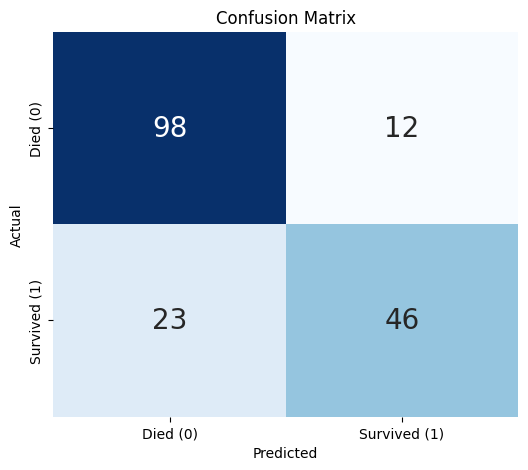

In [ ]:
cm = confusion_matrix(y_test, predictions)

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", cbar=False,
            xticklabels=["Died (0)", "Survived (1)"],
            yticklabels=["Died (0)", "Survived (1)"],
            annot_kws={"size": 20})
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()